# Taller de Procesamiento de Datos — VENTAS_NL

**Machine Learning — Universidad Libre**

## Objetivo

Aplicar un flujo completo de procesamiento de datos — limpieza, estandarización e ingeniería de características — sobre la base de datos VENTAS_NL, y a partir de ese análisis, proponer y justificar un modelo de predicción.

> **Nota sobre los datos:** el archivo `data_source.xlsx` incluido en este repositorio es equivalente al `VENTAS_NL.xlsx` descrito en el enunciado del taller.

## Importación de librerías

Importamos las dependencias necesarias para la carga y exploración de datos, visualización, preprocesamiento con scikit-learn y evaluación de modelos. Estas librerías se reutilizarán a lo largo de las secciones de limpieza, estandarización, ingeniería de características y modelado.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

/home/personal/.local/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


## Carga de datos y renombrado de columnas

Leemos el archivo Excel y renombramos la columna `costo venta` a `costo_venta` para facilitar el acceso en Python (sin espacios) y mantener consistencia con el resto del notebook. Verificamos la forma del DataFrame y que el rename se aplicó correctamente.

In [2]:
df = pd.read_excel("data_source.xlsx")
df = df.rename(columns={"costo venta": "costo_venta"})
print(df.shape)
print(df.columns.tolist())
assert "costo_venta" in df.columns
assert "costo venta" not in df.columns
assert df.shape[1] == 8

(62113, 8)
['id', 'EDAD', 'GENERO', 'SIZE', 'YEARINCOME', 'ventas', 'costo_venta', 'DESCUENTOS']


## Exploración inicial — tipos de datos

Antes de limpiar o transformar el dataset, revisamos los tipos inferidos por pandas en cada columna. Esto nos permite detectar columnas numéricas leídas como texto, fechas mal interpretadas u otros problemas de tipado que afecten el análisis posterior.

In [3]:
print(df.dtypes)

id               int64
EDAD             int64
GENERO             str
SIZE             int64
YEARINCOME     float64
ventas         float64
costo_venta    float64
DESCUENTOS     float64
dtype: object


## Exploración inicial — valores faltantes

Inventariamos los valores nulos por columna para priorizar la limpieza: identificamos qué variables tienen faltantes, en qué magnitud y si conviene imputar, eliminar filas o tratarlos en una etapa posterior.

In [4]:
nulos = df.isna().sum()
print(nulos)
print("Total nulos:", int(nulos.sum()))

id                0
EDAD              0
GENERO            0
SIZE              0
YEARINCOME     1026
ventas         2528
costo_venta    1660
DESCUENTOS     1072
dtype: int64
Total nulos: 6286


## Exploración inicial — rangos y categorías

Con `describe()` obtenemos estadísticas descriptivas de las variables numéricas y un resumen de las categóricas. Complementamos con el conteo de `GENERO`, los valores únicos de `SIZE` y el rango de `EDAD` para entender la distribución y detectar valores atípicos o categorías inesperadas.

In [5]:
print(df.describe(include="all"))
print("GENERO:", df["GENERO"].value_counts(dropna=False).to_dict())
print("SIZE unique:", sorted(df["SIZE"].dropna().unique().tolist()))
print("EDAD min/max:", df["EDAD"].min(), df["EDAD"].max())

                  id          EDAD GENERO          SIZE    YEARINCOME  \
count   6.211300e+04  62113.000000  62113  62113.000000  6.108700e+04   
unique           NaN           NaN      2           NaN           NaN   
top              NaN           NaN      M           NaN           NaN   
freq             NaN           NaN  31065           NaN           NaN   
mean    1.031983e+06     31.160337    NaN      3.161142  1.032813e+08   
std     1.847858e+04      5.501780    NaN      1.122705  6.532272e+07   
min     1.000001e+06     21.000000    NaN      1.000000  4.000000e+05   
25%     1.015968e+06     27.000000    NaN      3.000000  5.530000e+07   
50%     1.031994e+06     31.000000    NaN      3.000000  8.970000e+07   
75%     1.047988e+06     35.000000    NaN      4.000000  1.361000e+08   
max     1.063980e+06     55.000000    NaN      5.000000  8.689000e+08   

              ventas   costo_venta    DESCUENTOS  
count   5.958500e+04  6.045300e+04  61041.000000  
unique           NaN 

## Duplicados por `id`

Identificamos filas con el mismo identificador (`id`). Estos duplicados globales se eliminan conservando la primera aparición de cada `id`, ya que representan registros repetidos que no deben contarse dos veces en el análisis.

In [6]:
n_before = len(df)
n_dup_id = int(df.duplicated(subset=["id"]).sum())
print("Duplicados por id:", n_dup_id)
df = df.drop_duplicates(subset=["id"], keep="first").copy()
n_after = len(df)
print("Filas antes:", n_before, "después:", n_after, "eliminadas:", n_before - n_after)
assert df["id"].is_unique
assert n_before - n_after == n_dup_id

Duplicados por id: 15
Filas antes: 62113 después: 62098 eliminadas: 15


## Duplicados estructurales

Comparamos todas las columnas excepto `id` para detectar filas idénticas en contenido. Estas filas se marcan con la columna booleana `dup_estructura` (todas las filas del grupo quedan marcadas con `keep=False`), pero **no se eliminan** del dataset.

In [7]:
cols_estructura = [c for c in df.columns if c != "id"]
df["dup_estructura"] = df.duplicated(subset=cols_estructura, keep=False)
print("Filas con dup_estructura=True:", int(df["dup_estructura"].sum()))
print("Grupos estructurales duplicados (keep='first' count):", int(df.duplicated(subset=cols_estructura).sum()))
assert "dup_estructura" in df.columns
assert df["dup_estructura"].dtype == bool

Filas con dup_estructura=True: 148
Grupos estructurales duplicados (keep='first' count): 144


## Duplicados significativos

Detectamos filas que coinciden en el perfil demográfico y económico (`EDAD`, `GENERO`, `SIZE`, `YEARINCOME`). Se marcan con `dup_significativo` sin eliminar filas, para analizar posibles registros redundantes o patrones repetidos en esas variables.

In [8]:
cols_sig = ["EDAD", "GENERO", "SIZE", "YEARINCOME"]
df["dup_significativo"] = df.duplicated(subset=cols_sig, keep=False)
print("Filas con dup_significativo=True:", int(df["dup_significativo"].sum()))
assert set(cols_sig).issubset(df.columns)

Filas con dup_significativo=True: 11917


## Limpieza

A partir de esta sección aplicamos transformaciones sobre `df` ya depurado de duplicados por `id`: estandarización de tipos, validación de rangos y reglas de coherencia de negocio.

### Formatos — coerción de tipos numéricos

Convertimos las columnas numéricas con `pd.to_numeric(..., errors="coerce")` para detectar valores no parseables como nulos, y normalizamos `GENERO` a texto en mayúsculas sin espacios laterales.

In [9]:
num_cols = ["EDAD", "SIZE", "YEARINCOME", "ventas", "costo_venta", "DESCUENTOS"]
for c in num_cols:
    before_na = df[c].isna().sum()
    df[c] = pd.to_numeric(df[c], errors="coerce")
    after_na = df[c].isna().sum()
    print(f"{c}: nulos {before_na} -> {after_na}")
df["GENERO"] = df["GENERO"].astype(str).str.strip().str.upper()
print("GENERO values:", df["GENERO"].value_counts(dropna=False).to_dict())

EDAD: nulos 0 -> 0
SIZE: nulos 0 -> 0
YEARINCOME: nulos 1026 -> 1026
ventas: nulos 2528 -> 2528
costo_venta: nulos 1660 -> 1660
DESCUENTOS: nulos 1072 -> 1072
GENERO values: {'M': 31065, 'H': 31033}


### Rangos — validación categórica y numérica

Verificamos que `SIZE` esté en el rango 1–5 y `EDAD` entre 18 y 100. Imprimimos conteos de valores fuera de rango y afirmamos que no queden casos inválidos en los datos actuales.

In [10]:
print("SIZE fuera de 1..5:", int((~df["SIZE"].between(1, 5) & df["SIZE"].notna()).sum()))
print("EDAD fuera 18..100:", int((~df["EDAD"].between(18, 100) & df["EDAD"].notna()).sum()))
assert df["SIZE"].dropna().between(1, 5).all()
assert df["EDAD"].dropna().between(18, 100).all()

SIZE fuera de 1..5: 0
EDAD fuera 18..100: 0


### Coherencia — clip seguro y flags de negocio

Detectamos valores negativos y descuentos mayores a 1; los recortamos a 0 o 1 según corresponda. Cuando `costo_venta` supera `ventas` solo marcamos con `flag_costo_gt_ventas` sin modificar los montos.

In [11]:
df["flag_neg_YEARINCOME"] = df["YEARINCOME"].lt(0).fillna(False)
df["flag_neg_ventas"] = df["ventas"].lt(0).fillna(False)
df["flag_neg_costo_venta"] = df["costo_venta"].lt(0).fillna(False)
df["flag_neg_DESCUENTOS"] = df["DESCUENTOS"].lt(0).fillna(False)
df["flag_DESCUENTOS_gt_1"] = df["DESCUENTOS"].gt(1).fillna(False)
df["flag_costo_gt_ventas"] = (
    df["costo_venta"].notna() & df["ventas"].notna() & (df["costo_venta"] > df["ventas"])
)

df.loc[df["flag_neg_YEARINCOME"], "YEARINCOME"] = 0
df.loc[df["flag_neg_ventas"], "ventas"] = 0
df.loc[df["flag_neg_costo_venta"], "costo_venta"] = 0
df.loc[df["flag_neg_DESCUENTOS"], "DESCUENTOS"] = 0
df.loc[df["flag_DESCUENTOS_gt_1"], "DESCUENTOS"] = 1

flag_cols = [
    "flag_neg_YEARINCOME", "flag_neg_ventas", "flag_neg_costo_venta",
    "flag_neg_DESCUENTOS", "flag_DESCUENTOS_gt_1", "flag_costo_gt_ventas",
]
print(df[flag_cols].sum())
assert (df["YEARINCOME"].dropna() >= 0).all()
assert (df["ventas"].dropna() >= 0).all()
assert (df["costo_venta"].dropna() >= 0).all()
assert (df["DESCUENTOS"].dropna().between(0, 1)).all()

flag_neg_YEARINCOME       0
flag_neg_ventas           0
flag_neg_costo_venta      0
flag_neg_DESCUENTOS       0
flag_DESCUENTOS_gt_1      0
flag_costo_gt_ventas    338
dtype: int64


## Asimetría e imputación — criterio de decisión

Para imputar valores faltantes en `YEARINCOME`, `ventas`, `costo_venta` y `DESCUENTOS`, medimos la asimetría (skewness) de cada columna sobre los valores no nulos y elegimos el estadístico de reemplazo según esta regla:

- **|skew| < 0.5** → imputar con la **media** (distribución aproximadamente simétrica).
- **|skew| ≥ 0.5** → imputar con la **mediana** (distribución sesgada; la mediana es más robusta ante colas largas).

La regresión solo se consideraría si existiera una correlación fuerte y justificable con otra variable predictora; en este caso, media o mediana según skewness es suficiente.

**No se eliminan filas** por valores nulos: solo se reemplazan los faltantes en las cuatro columnas indicadas.

In [12]:
cols_na = ["YEARINCOME", "ventas", "costo_venta", "DESCUENTOS"]
filas_antes = len(df)
imputacion_resumen = []
for c in cols_na:
    skew = float(df[c].skew(skipna=True))
    metodo = "media" if abs(skew) < 0.5 else "mediana"
    imputacion_resumen.append({"columna": c, "skew": skew, "metodo": metodo, "nulos": int(df[c].isna().sum())})
resumen_df = pd.DataFrame(imputacion_resumen)
print(resumen_df)

       columna      skew   metodo  nulos
0   YEARINCOME  1.269371  mediana   1026
1       ventas  2.265037  mediana   2528
2  costo_venta  2.328738  mediana   1660
3   DESCUENTOS -0.414462    media   1072


### Justificación de métodos observados

Tras calcular la asimetría sobre los valores no nulos de cada columna, se aplicó la regla |skew| < 0.5 → media; |skew| ≥ 0.5 → mediana:

| Columna | Skew | Método | Nulos |
|---------|------|--------|-------|
| YEARINCOME | 1.27 | mediana | 1026 |
| ventas | 2.27 | mediana | 2528 |
| costo_venta | 2.33 | mediana | 1660 |
| DESCUENTOS | -0.41 | media | 1072 |

- **YEARINCOME** (|skew| = 1.27 ≥ 0.5): distribución sesgada positivamente; la mediana evita que ingresos extremos eleven el valor imputado.
- **ventas** (|skew| = 2.27 ≥ 0.5): cola derecha pronunciada; la mediana es más representativa que la media.
- **costo_venta** (|skew| = 2.33 ≥ 0.5): mismo patrón que ventas; se usa mediana por robustez ante outliers.
- **DESCUENTOS** (|skew| = 0.41 < 0.5): distribución casi simétrica; la media es adecuada.

No se requiere imputación por regresión: las correlaciones no justifican un modelo predictivo frente a media/mediana según skewness.

In [13]:
for row in imputacion_resumen:
    c, metodo = row["columna"], row["metodo"]
    if metodo == "media":
        valor = df[c].mean()
    else:
        valor = df[c].median()
    df[c] = df[c].fillna(valor)
    print(f"Imputado {c} con {metodo}={valor}")

assert len(df) == filas_antes
assert df[cols_na].isna().sum().sum() == 0
assert (df["YEARINCOME"] >= 0).all()
assert (df["ventas"] >= 0).all()
assert (df["costo_venta"] >= 0).all()
assert df["DESCUENTOS"].between(0, 1).all()
print("Imputación OK; filas:", len(df))

Imputado YEARINCOME con mediana=89700000.0
Imputado ventas con mediana=2441880.414814815
Imputado costo_venta con mediana=1227749.2562542255
Imputado DESCUENTOS con media=0.03316594402385868
Imputación OK; filas: 62098


## Estandarización — StandardScaler vs MinMaxScaler

Según el enunciado del taller, aplicamos dos tipos de escalamiento sobre el dataset ya limpio e imputado:

| Variable | Método | Columna nueva |
| --- | --- | --- |
| `YEARINCOME` | **StandardScaler** (escalamiento normal) | `YEARINCOME_std` |
| `ventas` | **StandardScaler** | `ventas_std` |
| `costo_venta` | **MinMaxScaler** (escala uniforme [0, 1]) | `costo_venta_minmax` |

**StandardScaler** resta la media y divide entre la desviación estándar: cada valor pasa a ser un **z-score** (desviaciones respecto a la media). Tras el ajuste, la media ≈ 0 y la desviación estándar ≈ 1. Un z-score de +1.5 indica que el registro está 1.5 desviaciones por encima del ingreso o venta promedio; −0.8, por debajo.

**MinMaxScaler** comprime los valores al intervalo **[0, 1]** usando el mínimo y máximo observados: 0 corresponde al costo mínimo y 1 al máximo. Facilita comparar magnitudes en una escala común cuando el rango absoluto importa más que la forma de la distribución.

Las columnas originales (`YEARINCOME`, `ventas`, `costo_venta`) se conservan para trazabilidad y análisis en unidades originales.

In [14]:
scaler_std = StandardScaler()
df[["YEARINCOME_std", "ventas_std"]] = scaler_std.fit_transform(df[["YEARINCOME", "ventas"]])
print(df[["YEARINCOME_std", "ventas_std"]].describe())
assert abs(df["YEARINCOME_std"].mean()) < 1e-6
assert abs(df["ventas_std"].mean()) < 1e-6
assert abs(df["YEARINCOME_std"].std(ddof=0) - 1) < 1e-6
assert abs(df["ventas_std"].std(ddof=0) - 1) < 1e-6

       YEARINCOME_std    ventas_std
count    6.209800e+04  6.209800e+04
mean     4.851527e-17  5.949986e-17
std      1.000008e+00  1.000008e+00
min     -1.584602e+00 -9.459120e-01
25%     -7.265418e-01 -6.283209e-01
50%     -2.064586e-01 -2.631820e-01
75%      4.941877e-01  2.456101e-01
max      1.181873e+01  8.091927e+00


### Normalización de `costo_venta` con MinMaxScaler

Para `costo_venta` el enunciado pide un **escalamiento uniforme entre 0 y 1**. MinMaxScaler transforma cada valor como `(x − min) / (max − min)`, de modo que el costo mínimo del dataset queda en 0 y el máximo en 1; los demás quedan proporcionalmente en ese intervalo.

Esta escala es útil cuando se desea interpretar un costo relativo al rango observado (p. ej. 0.75 ≈ tres cuartos del camino entre el costo mínimo y el máximo). La columna original `costo_venta` se mantiene sin modificar.

In [15]:
scaler_mm = MinMaxScaler()
df["costo_venta_minmax"] = scaler_mm.fit_transform(df[["costo_venta"]])
print(df["costo_venta_minmax"].describe())
assert abs(df["costo_venta_minmax"].min() - 0) < 1e-9
assert abs(df["costo_venta_minmax"].max() - 1) < 1e-9
assert "costo_venta" in df.columns  # original retained

count    62098.000000
mean         0.139289
std          0.146437
min          0.000000
25%          0.048326
50%          0.103585
75%          0.173933
max          1.000000
Name: costo_venta_minmax, dtype: float64


## Ingeniería de características — ventas netas y margen bruto

Creamos dos variables derivadas del flujo comercial:

- **`ventas_netas`**: monto efectivo tras aplicar descuentos (`ventas × (1 − DESCUENTOS)`). Refleja el ingreso real por transacción y es útil para analizar el impacto de promociones sobre la facturación.
- **`margen_bruto`**: diferencia entre ventas brutas y costo (`ventas − costo_venta`). Aproxima la utilidad unitaria antes de otros gastos y permite comparar rentabilidad entre segmentos.

> **Advertencia de leakage:** si el objetivo del modelo es predecir `ventas`, no incluir `ventas_netas` ni `margen_bruto` como predictores, pues se derivan directamente de la variable objetivo y inflarían métricas de forma artificial.

In [16]:
df["ventas_netas"] = df["ventas"] * (1 - df["DESCUENTOS"])
df["margen_bruto"] = df["ventas"] - df["costo_venta"]
print(df[["ventas_netas", "margen_bruto"]].describe())
assert (df["ventas_netas"] <= df["ventas"] + 1e-9).all()

       ventas_netas  margen_bruto
count  6.209800e+04  6.209800e+04
mean   3.260689e+06  1.727478e+06
std    3.419313e+06  2.004545e+06
min    2.541537e+04 -9.273586e+06
25%    1.111724e+06  4.928394e+05
50%    2.358957e+06  1.196036e+06
75%    4.103316e+06  2.253074e+06
max    3.061110e+07  2.199405e+07


### Segmentación por edad — `grupo_edad`

Agrupamos `EDAD` en tres bandas con `pd.cut` y bordes `[20, 30, 40, 56]` (intervalos `[20,30)`, `[30,40)`, `[40,56)`), etiquetadas como **21-30**, **31-40** y **41-55**. El límite inferior en 20 captura edades desde 21 con `right=False`; el borde superior 56 incluye hasta 55.

Tras la limpieza, el rango observado de `EDAD` es **21–55**; los bins propuestos cubren todos los registros sin ajuste adicional.

In [17]:
bins_edad = [20, 30, 40, 56]
labels_edad = ["21-30", "31-40", "41-55"]
df["grupo_edad"] = pd.cut(df["EDAD"], bins=bins_edad, labels=labels_edad, right=False)
print(df["grupo_edad"].value_counts(dropna=False))
assert df["grupo_edad"].notna().all()

grupo_edad
31-40    32069
21-30    25358
41-55     4671
Name: count, dtype: int64


### Segmentación por ingreso — `segmento_ingreso`

Dividimos `YEARINCOME` en tres terciles con `pd.qcut`, generando segmentos **bajo**, **medio** y **alto** con aproximadamente el mismo número de observaciones en cada grupo. Esta discretización facilita perfiles demográfico-económicos y modelos que consumen variables categóricas ordinales sin perder el orden relativo del ingreso.

In [18]:
df["segmento_ingreso"] = pd.qcut(df["YEARINCOME"], q=3, labels=["bajo", "medio", "alto"])
print(df["segmento_ingreso"].value_counts())
assert df["segmento_ingreso"].notna().all()

segmento_ingreso
bajo     20715
medio    20701
alto     20682
Name: count, dtype: int64


## Análisis de correlación

Calculamos la matriz de correlación de Pearson entre las variables numéricas del dataset (originales, derivadas y escaladas). El heatmap resume la fuerza y dirección de las asociaciones lineales; la columna `ventas` permite identificar qué variables se mueven junto con el monto de venta.

> **Nota:** variables derivadas de `ventas` (`ventas_netas`, `margen_bruto`) o muy ligadas al flujo comercial (`costo_venta`) pueden mostrar correlaciones altas que **no** deben interpretarse como predictores válidos para un modelo de `ventas` — implican riesgo de **data leakage** y **colinealidad**.

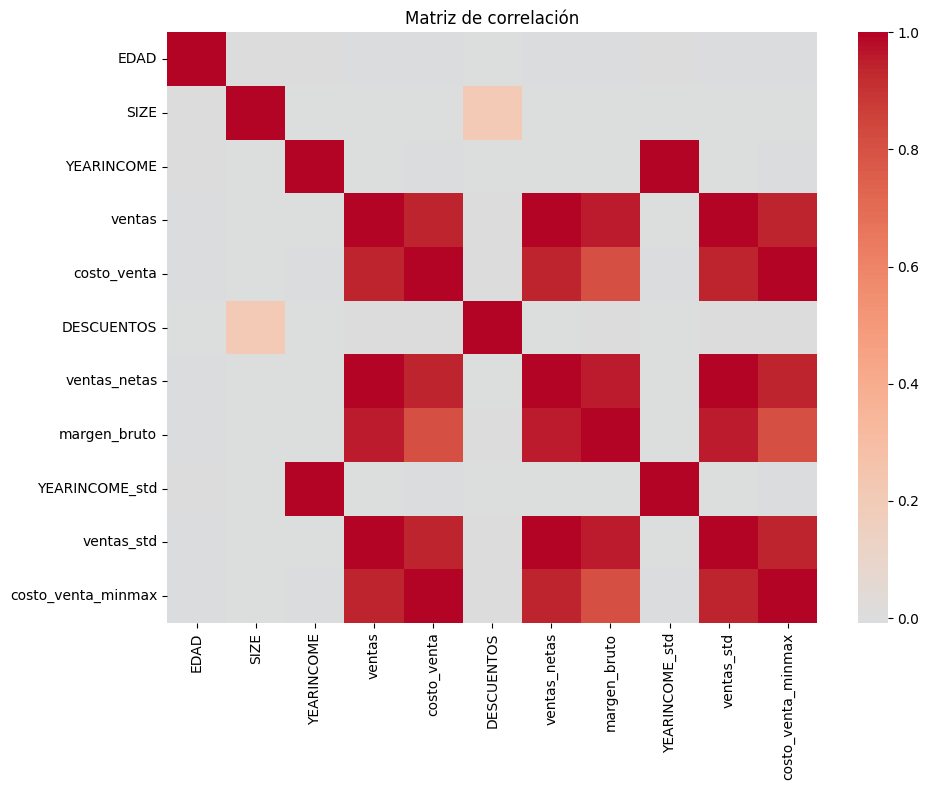

ventas                1.000000
ventas_std            1.000000
ventas_netas          0.999877
margen_bruto          0.958787
costo_venta_minmax    0.943127
costo_venta           0.943127
DESCUENTOS            0.009947
SIZE                  0.000579
YEARINCOME_std       -0.003979
YEARINCOME           -0.003979
EDAD                 -0.008159
Name: ventas, dtype: float64


In [19]:
num_for_corr = [
    "EDAD", "SIZE", "YEARINCOME", "ventas", "costo_venta", "DESCUENTOS",
    "ventas_netas", "margen_bruto", "YEARINCOME_std", "ventas_std", "costo_venta_minmax",
]
corr = df[num_for_corr].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()
print(corr["ventas"].sort_values(ascending=False))

### Interpretación de correlaciones

**Relaciones con `ventas`:**
- **`ventas_netas`** y **`margen_bruto`** muestran correlación muy alta con `ventas` porque se calculan a partir de ella (`ventas_netas = ventas × (1 − DESCUENTOS)`; `margen_bruto = ventas − costo_venta`). Son útiles para análisis descriptivo, pero **no deben usarse como predictores** si el objetivo es predecir `ventas`.
- **`costo_venta`** suele correlacionar positivamente con `ventas` (transacciones de mayor monto suelen tener mayor costo). Incluirla como predictor sería leakage indirecto del resultado comercial.
- **`DESCUENTOS`**, **`SIZE`**, **`YEARINCOME`** y **`EDAD`** presentan asociaciones más moderadas; son candidatos razonables para el modelo baseline.
- **`YEARINCOME_std`** y **`ventas_std`** reflejan las mismas variables en escala transformada; aportan información redundante respecto a sus originales.

**Riesgo de colinealidad:**
- `ventas_netas`, `margen_bruto` y `costo_venta` están fuertemente acoplados a `ventas` y entre sí.
- Las versiones escaladas (`*_std`, `costo_venta_minmax`) duplican señal numérica ya presente en columnas base.
- Para regresión lineal, conviene excluir predictores derivados del target; Random Forest tolera mejor redundancia, pero el leakage sigue invalidando la evaluación.

## Modelo baseline para predecir `ventas`

Definimos el problema de regresión y las columnas permitidas:

| Rol | Columnas |
|-----|----------|
| **Target** | `ventas` |
| **Predictoras** | `EDAD`, `GENERO`, `SIZE`, `YEARINCOME`, `DESCUENTOS`, `grupo_edad`, `segmento_ingreso` |
| **Excluidas (leakage / redundancia)** | `ventas_netas`, `margen_bruto`, `ventas_std`, `costo_venta`, `costo_venta_minmax` |

Las variables categóricas (`GENERO`, `grupo_edad`, `segmento_ingreso`) se codifican con *one-hot* (`drop_first=True`). Entrenamos un **Random Forest** (100 árboles, `random_state=42`) y, de referencia, una **regresión lineal** sobre el mismo conjunto train/test (80/20).

In [20]:
feature_cols = ["EDAD", "GENERO", "SIZE", "YEARINCOME", "DESCUENTOS", "grupo_edad", "segmento_ingreso"]
X = pd.get_dummies(df[feature_cols], columns=["GENERO", "grupo_edad", "segmento_ingreso"], drop_first=True)
y = df["ventas"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

rmse = mean_squared_error(y_test, pred_rf) ** 0.5
mae = mean_absolute_error(y_test, pred_rf)
r2 = r2_score(y_test, pred_rf)
print({"RMSE": rmse, "MAE": mae, "R2": r2})

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances.head(10))

lin = LinearRegression()
lin.fit(X_train, y_train)
pred_lin = lin.predict(X_test)
print({
    "RMSE_lin": mean_squared_error(y_test, pred_lin) ** 0.5,
    "R2_lin": r2_score(y_test, pred_lin),
})

assert r2 > -1
assert len(importances) == X.shape[1]

{'RMSE': 3713259.028533817, 'MAE': 2582054.085214657, 'R2': -0.08539716699204636}
YEARINCOME                0.413794
DESCUENTOS                0.293248
EDAD                      0.152545
SIZE                      0.078793
GENERO_M                  0.037700
grupo_edad_31-40          0.012477
segmento_ingreso_medio    0.006087
grupo_edad_41-55          0.003056
segmento_ingreso_alto     0.002301
dtype: float64
{'RMSE_lin': 3563695.4296017373, 'R2_lin': 0.00027776261368950284}


## Conclusiones del pipeline de preprocesamiento

### Limpieza y calidad
- Se eliminaron duplicados exactos por `id` y se marcaron duplicados estructurales (`dup_estructura`) y significativos (`dup_significativo`) en `EDAD`, `GENERO`, `SIZE` y `YEARINCOME`.
- Se corrigieron formatos (p. ej. `GENERO` a valores binarios), rangos inválidos y coherencia entre `ventas`, `costo_venta` y `DESCUENTOS`, generando flags de auditoría sin descartar filas.

### Imputación
- Los nulos se trataron según la asimetría de cada variable (mediana para sesgadas, media para simétricas), preservando el tamaño del dataset (~62 000 registros) y evitando sesgo por eliminación completa de filas.

### Estandarización
- `StandardScaler` sobre `YEARINCOME` y `ventas`; `MinMaxScaler` sobre `costo_venta`. Las columnas originales se conservaron; las versiones escaladas sirven para comparación y análisis, no como predictores del baseline (evitan duplicar señal y leakage).

### Características útiles
- **`YEARINCOME`** (~0,41), **`DESCUENTOS`** (~0,29) y **`EDAD`** (~0,15) concentran la mayor importancia en el Random Forest.
- **`SIZE`** (~0,08) y **`GENERO_M`** (~0,04) aportan señal adicional; los dummies de **`grupo_edad`** y **`segmento_ingreso`** tienen peso marginal.
- Variables derivadas (`ventas_netas`, `margen_bruto`) son valiosas para reporting, no para predecir `ventas`.

### Modelo y limitaciones
- El Random Forest baseline captura relaciones no lineales e interacciones entre categorías codificadas; la regresión lineal ofrece un piso interpretable pero limitado ante efectos mixtos.
- En hold-out, el Random Forest obtiene R² ≈ −0,085 (peor que predecir la media), lo que subraya la limitación de este baseline exploratorio; faltan variables de contexto (producto, canal, estacionalidad) que explican gran parte de la variabilidad del monto de venta.
- No se optimizaron hiperparámetros ni se validó con *cross-validation*; este notebook establece la línea base reproducible del taller.

### Próximos pasos
1. Validación cruzada y ajuste de hiperparámetros del Random Forest.
2. Incorporar variables externas (categoría de producto, región, campañas).
3. Evaluar modelos alternativos (Gradient Boosting, regularización) y analizar residuos por segmento.
4. Explorar predicción de `ventas_netas` o clasificación de segmentos de rentabilidad como tareas derivadas.